### Animal Faces Classification Task: Understanding Underfitting, Overfitting, Regularization, Dropout and Hyperparameter Tuning and reviweing validation

In [1]:
# Import necessary libraries
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from keras.src.legacy.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.regularizers import l1, l2
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
import kagglehub

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [2]:
# Download the dataset
path = kagglehub.dataset_download("andrewmvd/animal-faces")
print("Path to dataset files:", path)

# Define paths (assuming standard structure: afhq/train and afhq/val with subfolders cat, dog, wild)
data_dir = os.path.join(path, 'afhq')
train_dir = os.path.join(data_dir, 'train')
test_dir = os.path.join(data_dir, 'val')  # This is the test set in this task

num_classes = 3  # cat, dog, wild

# This is new way to load data(you can even set batch size by it if you want!):
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.95)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    class_mode='categorical',
    subset='training'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    class_mode='categorical',
    shuffle=False
)

# Note: The 'val' folder is used as the test set here. If you need a validation set, split the data from the train set.

Path to dataset files: C:\Users\mhkaz\.cache\kagglehub\datasets\andrewmvd\animal-faces\versions\1
Found 732 images belonging to 3 classes.
Found 1500 images belonging to 3 classes.


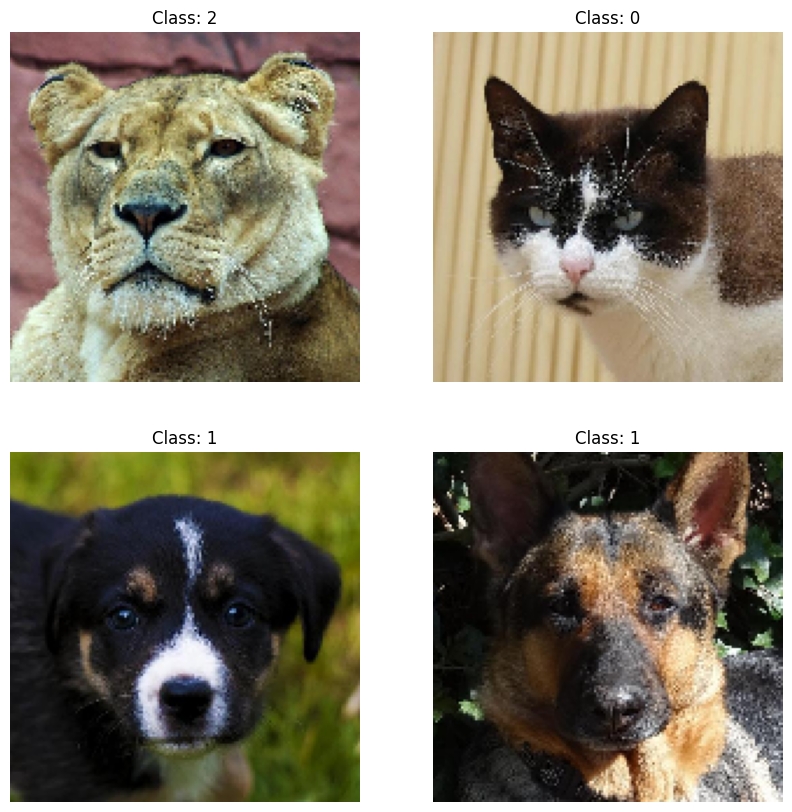

In [3]:
# Optional: Visualize a batch of images to confirm loading
import matplotlib.pyplot as plt

images, labels = next(train_generator)  # Get one batch
plt.figure(figsize=(10, 10))
for i in range(4):  # Show first 4 images
    plt.subplot(2, 2, i+1)
    plt.imshow(images[i])
    plt.title(f'Class: {labels[i].argmax()}')
    plt.axis('off')
plt.show()

In [4]:
# Function to plot training history (accuracy and loss curves)
def plot_history(history, title):
    plt.figure(figsize=(12, 4))
    
    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    if 'val_accuracy' in history.history:
        plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.show()

# Function to evaluate on test set
def evaluate_model(model):
    test_loss, test_acc = model.evaluate(test_generator)
    print(f'Test Accuracy: {test_acc:.4f}')
    return test_acc

c:\Users\mhkaz\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 67500)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │       540,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 540,035 (2.06 MB)

 Trainable params: 540,035 (2.06 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5


c:\Users\mhkaz\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.3415 - loss: 4.3653
Epoch 2/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.3525 - loss: 1.0985
Epoch 3/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.3525 - loss: 1.0984
Epoch 4/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.3525 - loss: 1.0984
Epoch 5/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.3525 - loss: 1.0983


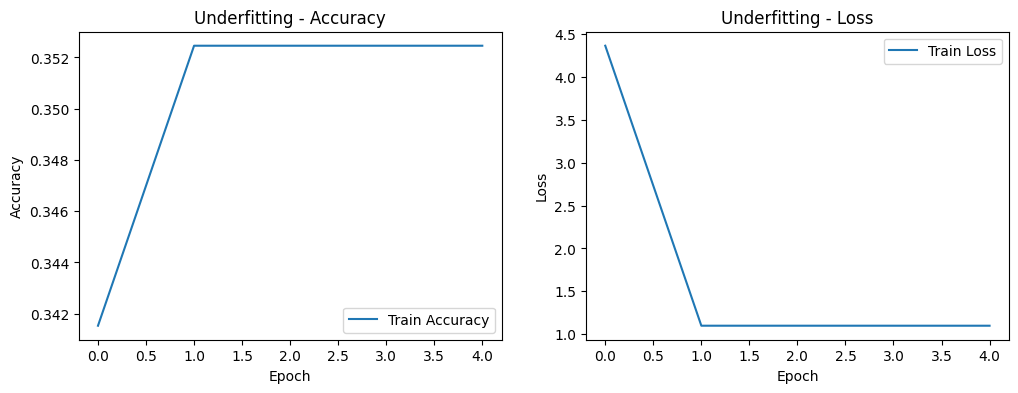

47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.3333 - loss: 1.0987
Test Accuracy: 0.3333


0.3333333432674408

In [5]:
# Cell 1: Create an underfitting model
# Goal: Design a simple ANN (e.g., few layers, small neurons) that underfits the data.
# Train it on the train set (no validation split needed here).
# Observe high bias: similar poor performance on train and test.
# After training, use plot_history(history, 'Underfitting') and evaluate_model(model)

# Your code here:
# model = Sequential([...])  # Simple CNN or MLP
# model.compile(...)
# history = model.fit(train_generator, epochs=...)
# plot_history(...)
# evaluate_model(...)

model_underfit = Sequential([
    Flatten(input_shape=(150, 150, 3)),
    Dense(8, activation='relu'),
    Dense(3, activation='softmax')
])

model_underfit.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_underfit.summary()

history_underfit = model_underfit.fit(
    train_generator,
    epochs=5,
)

plot_history(history_underfit,"Underfitting")

evaluate_model(model_underfit)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 67500)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     8,640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,706,563 (33.21 MB)

 Trainable params: 8,706,563 (33.21 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.3361 - loss: 3.2815
Epoch 2/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.4617 - loss: 1.1145
Epoch 3/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.5123 - loss: 1.0369
Epoch 4/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.6079 - loss: 0.8571
Epoch 5/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.6817 - loss: 0.7153
Epoch 6/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.7240 - loss: 0.6323
Epoch 7/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.7391 - loss: 0.6105
Epoch 8/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.7691 - loss: 0.5499
Epoch 9/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.8074 - loss: 0.5076
Epoch 10/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.7910 - loss: 0.5072
Epoch 11/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.8101 - loss: 0.4918
Epoch 12/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy:

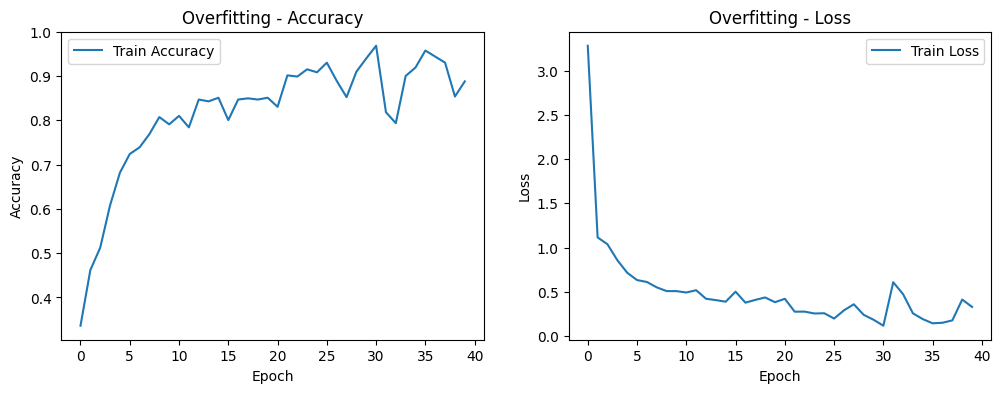

47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.6640 - loss: 0.9696
Test Accuracy: 0.6640


0.6639999747276306

In [6]:
# Cell 2: Create an overfitting model
# Goal: Design a complex ANN (e.g., many layers, large neurons) that overfits.
# Train for many epochs without regularization.
# Observe low bias but high variance: good on train, poor on test.
# After training, use plot_history(history, 'Overfitting') and evaluate_model(model)

# Your code here:
# model = Sequential([...])  # Complex model
# model.compile(...)
# history = model.fit(train_generator, epochs=...)
# plot_history(...)
# evaluate_model(...)

model_overfit = Sequential([
    Flatten(input_shape=(150, 150, 3)),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(3, activation='softmax')
])

model_overfit.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'])

model_overfit.summary()

history_overfit = model_overfit.fit(
    train_generator,
    epochs=40,
)

plot_history(history_overfit,"Overfitting")

evaluate_model(model_overfit)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 67500)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     8,640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,706,563 (33.21 MB)

 Trainable params: 8,706,563 (33.21 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.3702 - loss: 152.8432
Epoch 2/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.3716 - loss: 53.6420
Epoch 3/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.3525 - loss: 33.9690
Epoch 4/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.3525 - loss: 24.0890
Epoch 5/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.3525 - loss: 17.5202
Epoch 6/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.3525 - loss: 13.4145
Epoch 7/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.3525 - loss: 11.6044
Epoch 8/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.3525 - loss: 11.2560
Epoch 9/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.3525 - loss: 11.1935
Epoch 10/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.3525 - loss: 11.1810
Epoch 11/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.3525 - loss: 11.1748
Epoch 12/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step

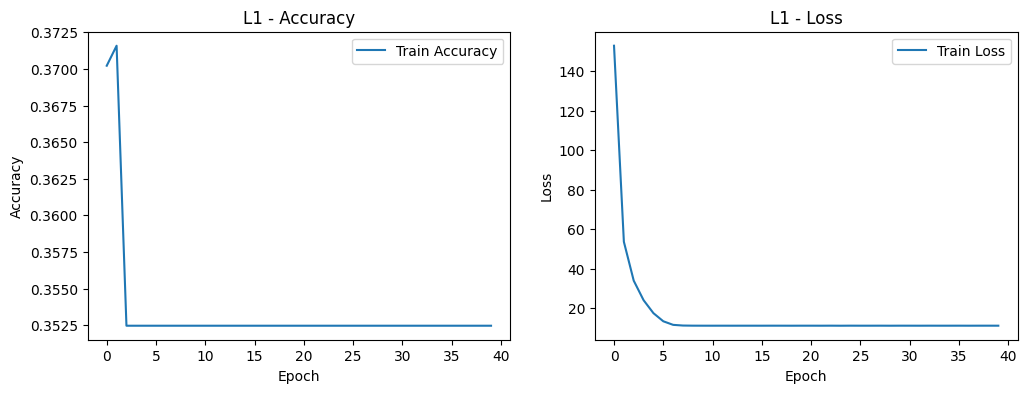

47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.3333 - loss: 11.1765
Test Accuracy: 0.3333


0.3333333432674408

In [7]:
# Cell 3: Add L1 Regularization
# Goal: Modify a model (perhaps the overfitting one) by adding L1 regularizers to layers.
# e.g., Dense(..., kernel_regularizer=l1(0.01))
# Train and observe how it reduces overfitting.
# Optional: Split validation from train if needed (e.g., validation_split=0.2 in fit)
# After training, plot and evaluate.

model_l1 = Sequential([
    Flatten(input_shape=(150, 150, 3)),
    Dense(128, activation='relu', kernel_regularizer=l1(0.01)),
    Dense(128, activation='relu', kernel_regularizer=l1(0.01)),
    Dense(128, activation='relu', kernel_regularizer=l1(0.01)),
    Dense(128, activation='relu', kernel_regularizer=l1(0.01)),
    Dense(128, activation='relu', kernel_regularizer=l1(0.01)),
    Dense(3, activation='softmax')
])

model_l1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'])

model_l1.summary()

history_l1 = model_l1.fit(
    train_generator,
    epochs=40,
)

plot_history(history_l1,"L1")

evaluate_model(model_l1)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 67500)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │     8,640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,706,563 (33.21 MB)

 Trainable params: 8,706,563 (33.21 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.3538 - loss: 9.0872 
Epoch 2/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.4727 - loss: 6.0554
Epoch 3/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.4781 - loss: 4.8639
Epoch 4/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.5642 - loss: 4.0898
Epoch 5/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.6175 - loss: 3.5153
Epoch 6/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.6626 - loss: 3.1764
Epoch 7/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.7063 - loss: 2.9039
Epoch 8/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.7022 - loss: 2.8254
Epoch 9/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.7117 - loss: 2.7047
Epoch 10/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.6995 - loss: 2.7074
Epoch 11/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.7500 - loss: 2.6171
Epoch 12/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy

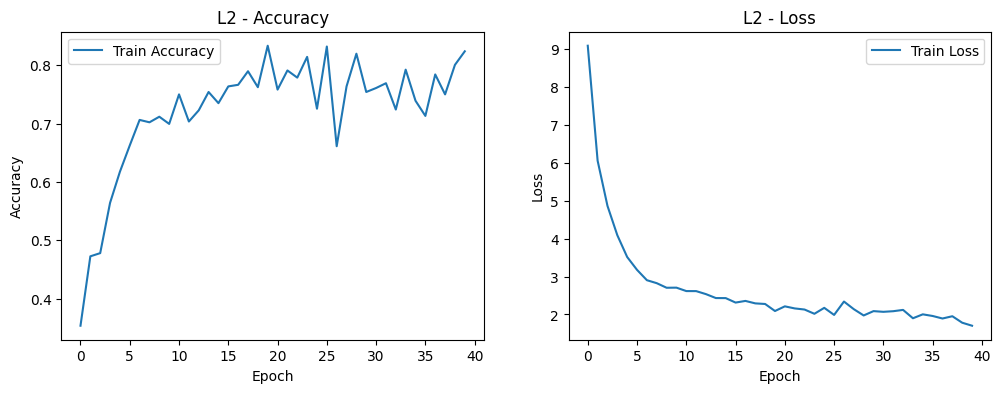

47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.6540 - loss: 2.0836
Test Accuracy: 0.6540


0.6539999842643738

In [8]:
# Cell 4: Add L2 Regularization
# Goal: Similar to above, but use L2 (weight decay).
# e.g., Dense(..., kernel_regularizer=l2(0.01))
# Compare with L1.
# Optional validation split.
# Plot and evaluate.

model_l2 = Sequential([
    Flatten(input_shape=(150, 150, 3)),
    Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(3, activation='softmax')
])

model_l2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'])

model_l2.summary()

history_l2 = model_l2.fit(
    train_generator,
    epochs=40,
)

plot_history(history_l2,"L2")

evaluate_model(model_l2)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 67500)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │     8,640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,706,563 (33.21 MB)

 Trainable params: 8,706,563 (33.21 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.3128 - loss: 11.9111
Epoch 2/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.3429 - loss: 1.1626
Epoch 3/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.3497 - loss: 1.0995
Epoch 4/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.3525 - loss: 1.0981
Epoch 5/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.3525 - loss: 1.0981
Epoch 6/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.3525 - loss: 1.0978
Epoch 7/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.3525 - loss: 1.0973
Epoch 8/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.3525 - loss: 1.0984
Epoch 9/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.3538 - loss: 1.0959
Epoch 10/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.3525 - loss: 1.0982
Epoch 11/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.3511 - loss: 1.1008
Epoch 12/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy

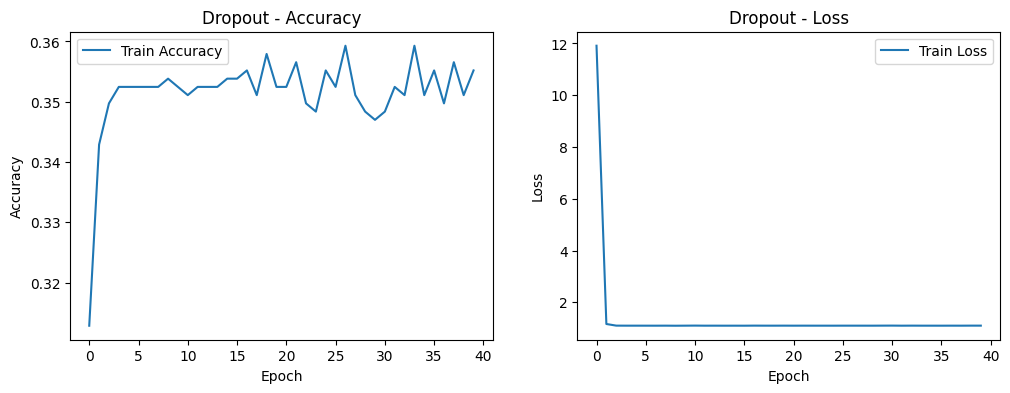

47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.3333 - loss: 1.0994
Test Accuracy: 0.3333


0.3333333432674408

In [9]:
# Cell 5: Add Dropout
# Goal: Add Dropout layers to prevent overfitting.
# e.g., Dropout(0.5) after Dense layers.
# Train, plot, evaluate.
# Optional validation.

model_drop = Sequential([
    Flatten(input_shape=(150, 150, 3)),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model_drop.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'])

model_drop.summary()

history_drop = model_drop.fit(
    train_generator,
    epochs=40,
)

plot_history(history_drop,"Dropout")

evaluate_model(model_drop)

Found 11706 images belonging to 3 classes.
Found 2924 images belonging to 3 classes.


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 67500)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │     8,640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,706,563 (33.21 MB)

 Trainable params: 8,706,563 (33.21 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
366/366 ━━━━━━━━━━━━━━━━━━━━ 31s 82ms/step - accuracy: 0.5916 - loss: 0.9988 - val_accuracy: 0.7014 - val_loss: 0.7160
Epoch 2/40
366/366 ━━━━━━━━━━━━━━━━━━━━ 31s 84ms/step - accuracy: 0.7233 - loss: 0.6664 - val_accuracy: 0.6518 - val_loss: 0.8690
Epoch 3/40
366/366 ━━━━━━━━━━━━━━━━━━━━ 33s 89ms/step - accuracy: 0.7606 - loss: 0.5961 - val_accuracy: 0.7391 - val_loss: 0.6457
Epoch 4/40
366/366 ━━━━━━━━━━━━━━━━━━━━ 32s 88ms/step - accuracy: 0.7846 - loss: 0.5530 - val_accuracy: 0.7780 - val_loss: 0.5637
Epoch 5/40
366/366 ━━━━━━━━━━━━━━━━━━━━ 32s 87ms/step - accuracy: 0.7917 - loss: 0.5275 - val_accuracy: 0.7955 - val_loss: 0.5341
Epoch 6/40
366/366 ━━━━━━━━━━━━━━━━━━━━ 32s 87ms/step - accuracy: 0.8051 - loss: 0.4978 - val_accuracy: 0.7828 - val_loss: 0.5507
Epoch 7/40
366/366 ━━━━━━━━━━━━━━━━━━━━ 32s 87ms/step - accuracy: 0.8044 - loss: 0.4958 - val_accuracy: 0.7924 - val_loss: 0.5359
Epoch 8/40
366/366 ━━━━━━━━━━━━━━━━━━━━ 32s 87ms/step - accuracy: 0.8225 - loss: 0.4639 - 

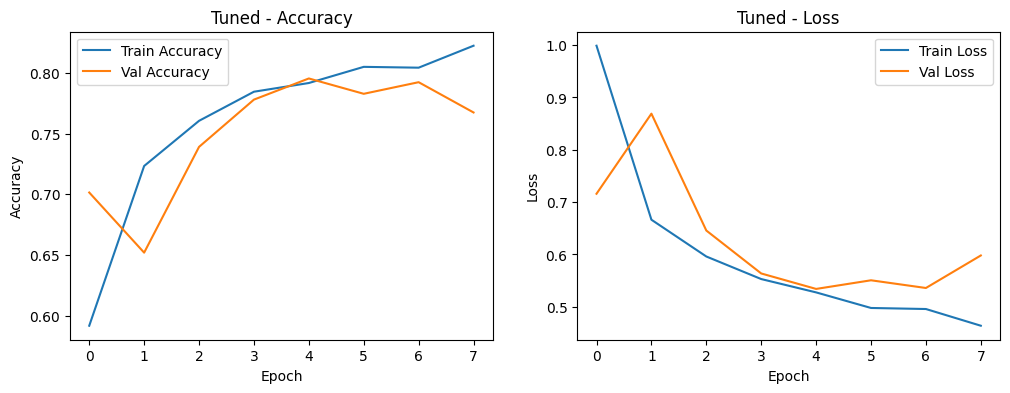

47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.7940 - loss: 0.5166
Test Accuracy: 0.7940


0.7940000295639038

In [10]:
# Cell 6: Hyperparameter Tuning
# Goal: Experiment with hyperparameters like learning rate, batch size, epochs, optimizer.
# Use callbacks like EarlyStopping if needed.
# e.g., optimizer=Adam(learning_rate=0.001)
# Try different values and see impact.
# Must use validation split here to tune.
# Plot and evaluate the best one.

datagen_tuned = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator_tuned = datagen_tuned.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator_tuned = datagen_tuned.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

model_tuned = Sequential([
    Flatten(input_shape=(150, 150, 3)),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(3, activation='softmax')
])

model_tuned.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

model_tuned.summary()

early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True,
    verbose=1
)

history_tuned = model_tuned.fit(
    train_generator_tuned,
    epochs=40,
    validation_data=validation_generator_tuned,
    callbacks=[early_stopping]
)

plot_history(history_tuned,"Tuned")

evaluate_model(model_tuned)

Found 11706 images belonging to 3 classes.
Found 2924 images belonging to 3 classes.


c:\Users\mhkaz\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,035,203 (72.61 MB)

 Trainable params: 19,035,203 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 75s 202ms/step - accuracy: 0.8391 - loss: 0.4060 - val_accuracy: 0.9381 - val_loss: 0.1662
Epoch 2/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 74s 201ms/step - accuracy: 0.9511 - loss: 0.1418 - val_accuracy: 0.9378 - val_loss: 0.1727
Epoch 3/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 74s 201ms/step - accuracy: 0.9713 - loss: 0.0771 - val_accuracy: 0.9545 - val_loss: 0.1298
Epoch 4/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 73s 200ms/step - accuracy: 0.9835 - loss: 0.0471 - val_accuracy: 0.9480 - val_loss: 0.1505
Epoch 5/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 73s 201ms/step - accuracy: 0.9869 - loss: 0.0356 - val_accuracy: 0.9542 - val_loss: 0.1410
Epoch 6/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 73s 200ms/step - accuracy: 0.9940 - loss: 0.0181 - val_accuracy: 0.9562 - val_loss: 0.1506
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.


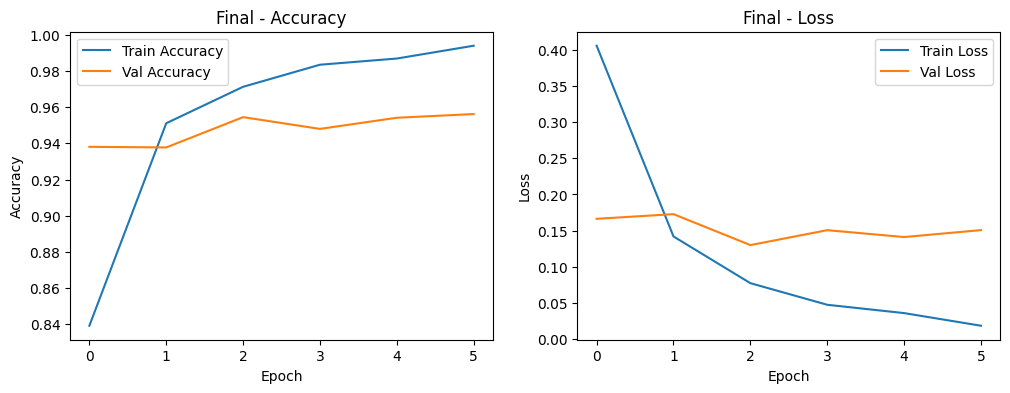

47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.9620 - loss: 0.1086
Test Accuracy: 0.9620


0.9620000123977661

In [11]:
# Cell 7: Combined Approach 
# Goal: Combine techniques (L1/L2, Dropout, Tuning) for balanced learning.
# Aim for good generalization: similar performance on train/val/test.
# Validation optional but recommended.
# Plot and evaluate.

final_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

final_train_generator = final_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

final_validation_generator = final_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

model_final = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(3, activation='softmax')
])

model_final.summary()

model_final.compile(optimizer=Adam(learning_rate=0.0005),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

final_early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history_final = model_final.fit(
    final_train_generator,
    epochs=50,
    validation_data=final_validation_generator,
    callbacks=[final_early_stopping]
)

plot_history(history_final,"Final")

evaluate_model(model_final)